Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")


df = pd.read_pickle("../data/features_v2.pkl")
with open("../models/model_v2.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer, get_vectorized_features_and_label

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
from python_editor.feature_generation_v2 import TRANSFORMED_FEATURES, LOG_FEATURES, generate_transformed_features

X_test, y_test = get_vectorized_features_and_label(test, TRANSFORMED_FEATURES)

Get predictions

In [4]:
y_pred = model.predict(X_test)

We slightly improved the asymmetry in residuals (now range from -6 to 6)

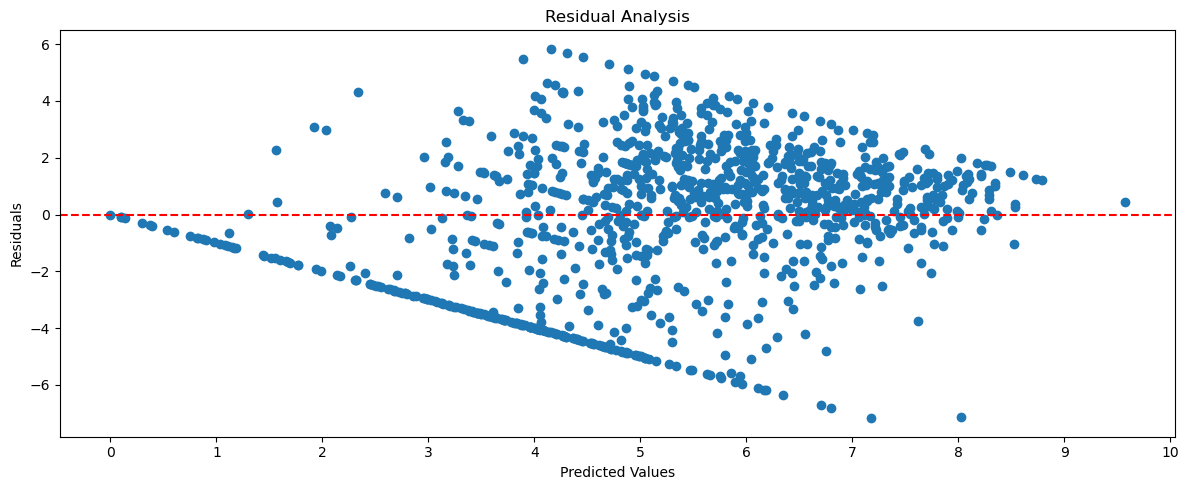

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [6]:
test.loc[:, "error"] = y_test - y_pred

/tmp/ipykernel_13608/4180407341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "error"] = y_test - y_pred


We examine top performing, most over estimated and most under estimated examples

In [7]:
import numpy as np
from python_editor.model_evaluation import get_top_k

test_og = test.copy()
test_og.loc[:, LOG_FEATURES] = np.expm1(test_og[LOG_FEATURES])

top_performing, most_over_estimated, most_under_estimated = get_top_k(test_og, "error", 3)

to_display = TRANSFORMED_FEATURES + ["pylint_score", "error"]
pd.set_option("display.max_columns", None)

Top performing examples have:

1- Functions/classes

2- Comments

In [8]:
top_performing[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
3241,7865.0,0.925234,46.631282,2.0,1.0,0.0,0.030303,0.0,0.020202,0.020202,0.0,0.010101,2.0,0.00,1.0,0.000000,0.000000
237,7161.0,0.794760,19.681892,17.0,0.0,1.0,0.049451,1.0,0.076923,0.060440,0.0,0.005495,10.0,0.25,1.0,7.102804,-0.004831
2471,1044.0,0.750000,23.090869,5.0,0.0,0.0,0.523810,0.0,0.047619,0.047619,0.0,0.047619,1.0,0.00,0.0,4.444444,-0.005018


Overestimated examples have:

1- Average to high number of characters

2- Docstring

In [9]:
most_over_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
932,2134.0,0.657143,25.142919,5.0,1.0,1.0,0.021739,1.0,0.195652,0.043478,0.0,0.021739,2.0,0.333333,1.0,0.000000,-7.179059
1982,5072.0,0.838235,21.980027,8.0,0.0,0.0,0.114035,1.0,0.043860,0.070175,0.0,0.017544,4.0,0.800000,0.0,0.877193,-7.146291
239,10891.0,0.888889,20.694417,11.0,0.0,1.0,0.098214,1.0,0.102679,0.062500,0.0,0.008929,6.5,0.250000,0.0,0.000000,-6.801666


Underestimated examples have: 

1- Average to low number of characters

2- No functions/classes

In [10]:
most_under_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1649,1185.0,0.944444,21.354805,1.0,0.0,1.0,0.019608,1.0,0.019608,0.0,0.0,0.0,0.0,0.0,0.0,10.0,5.839187
2774,246.0,0.700000,28.862800,1.0,0.0,0.0,0.000000,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,10.0,5.696602
2470,212.0,0.714286,11.754148,1.0,0.0,0.0,0.100000,1.0,0.400000,0.0,0.0,0.0,0.0,0.0,0.0,10.0,5.541351


Feature importance shows that the model relies on our new features

In [11]:
from python_editor.model_evaluation import get_feature_importance


embedding_dim = test["embedding"][0].shape[0]

importance_df = get_feature_importance(model, TRANSFORMED_FEATURES, embedding_dim)
importance_df.head(10)

,feature,importance
449,449,0.056048
770,line_length_std,0.038103
779,class_density,0.019980
137,137,0.017386
776,variable_density,0.013572
66,66,0.013218
672,672,0.013043
318,318,0.011331
561,561,0.010571
244,244,0.009006


In [12]:
X_train, y_train = get_vectorized_features_and_label(train, TRANSFORMED_FEATURES)

Shapley values confirms that new features are relevant

 99%|===================| 1049/1060 [01:00<00:00]        

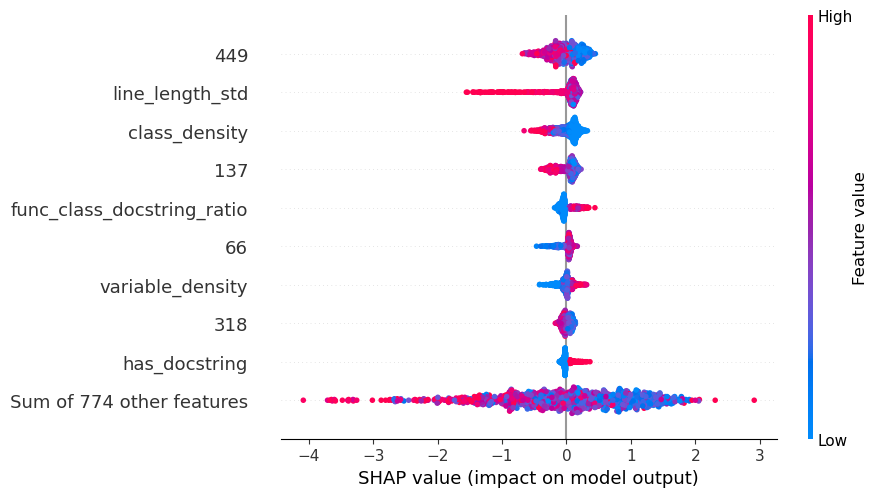

In [13]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, TRANSFORMED_FEATURES, X_train, X_test, embedding_dim)
shap.plots.beeswarm(shap_values)

We compare our model with pylint in terms of latency. Pylint is 2.5x faster than our model likely due to time used to generate embeddings. We will try to train a model on our generated features only.

In [14]:
from python_editor.data_processing import get_pylint_text
from python_editor.model_evaluation import compare_time

compare_time(get_pylint_text, generate_transformed_features, model, test["text"][0:50], embedding_dim=768)

100%|██████████| 50/50 [02:53<00:00,  3.46s/it]


{'model_time': 2.3215094661712645, 'pylint_time': 1.1392295598983764}